In [1]:
%pip install fiona geoseries

import fiona as fn
import geodatasets as gds
import geopandas as gpd
import pandas as pd
import pathlib as pb
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from geopandas import geoseries as gs
from geodatasets import get_path

Defaulting to user installation because normal site-packages is not writeable
ERROR: Could not find a version that satisfies the requirement geoseries (from versions: none)

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
ERROR: No matching distribution found for geoseries
Note: you may need to restart the kernel to use updated packages.


# Introduction

##### GeoPandas provides a high-level interface to the "matplotlib" library for making maps.
##### Mapping shapes is as easy as using the "plot()" method on a "GeoSeries" or "GeoDataFrame".
##### Also, have "choropleth maps" and "categorical maps"

### Loading some example data

xxx = gdf.read_file(
    gds.get_path('geoda.xxx)
)

In [ ]:
chicago = gpd.read_file(
    gds.get_path('geoda.chicago_commpop')
    )

groceries = gpd.read_file(gds.get_path('geoda.groceries'))

## Now plotting those GeoDataFrame

<Axes: >

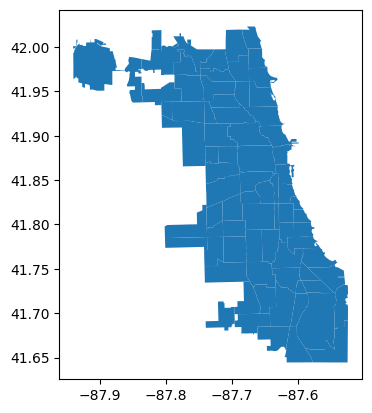

In [ ]:
chicago.head()                          ## Examine the chicago GeoDataFrame

chicago.plot()                          ## basic plot, single color

## Choropleth maps

<Axes: >

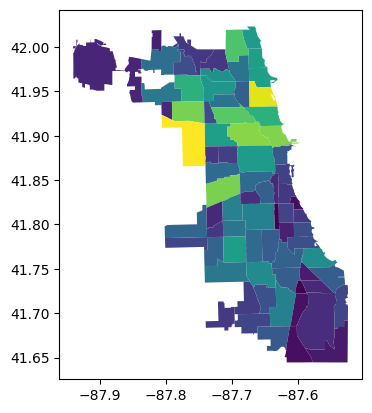

In [ ]:
chicago.plot(column='POP2010')              ## Plot by popluation

## Creating a legend

In [ ]:
chicago.plot(column='POP2010', legend=True)     ## Plot population estimates with an accurate legend

<Axes: >

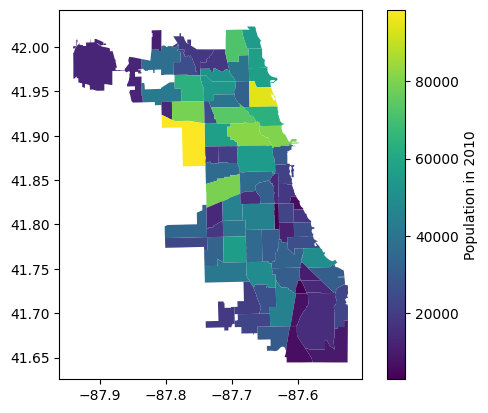

In [ ]:
chicago.plot(                                   ## Plot population estimates with an accurate legend
    column='POP2010',
    legend=True,
    legend_kwds = {'label':'Population in 2010'}
)

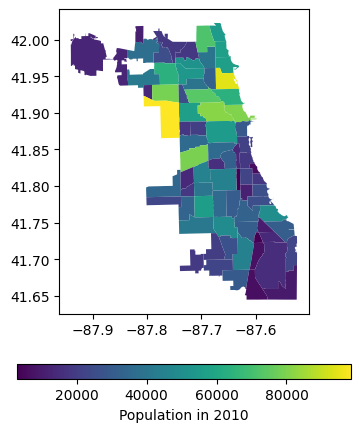

In [20]:
fig, ax = plt.subplots(1, 1)                    ## how many plot in matrix form like [1,1]
divider = make_axes_locatable(ax)

cax = divider.append_axes("bottom", size="5%", pad=0.5)

chicago.plot(
    column="POP2010",
    ax=ax,
    legend=True,
    cax=cax,
    legend_kwds={"label": "Population in 2010", "orientation": "horizontal"},
);


## Choosing Colors

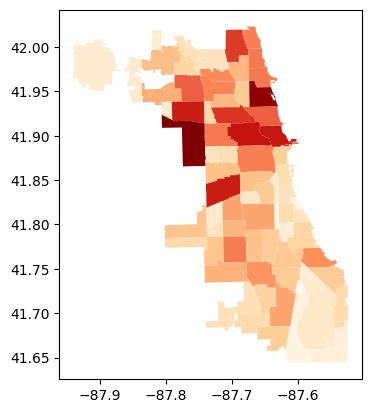

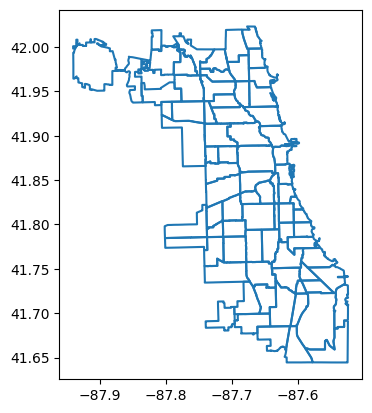

In [ ]:
chicago.plot(column='POP2010', cmap='OrRd')     ## changing color

chicago.boundary.plot();                        ## xxx.boundary.plot();

## Missing Data

#### In the GeoPandas Mapping, missing data means that a geographic feature (row) has no value for the column are trying to plor. Usually stored as 'NaN' or 'None'.

#### Real GIS datasets contain
#####    >   Missing census records
#####    >   Incomplete survey data
#####    >   Areas not measured
#####    >   Data collection errors

<Axes: >

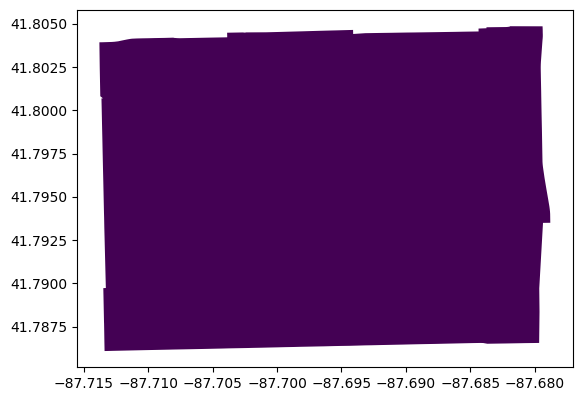

In [ ]:
import numpy as np

chicago.loc[np.random.choice(chicago.index, 30), 'POP2010'] = np.nan        ## randomly select x indices

chicago.plot(column='POP2010')

#### Customizing Missing Data Appearance

c:\Users\user\AppData\Local\Programs\Python\Python39\lib\site-packages\mapclassify\classifiers.py:1653: UserWarning: Not enough unique values in array to form 5 classes. Setting k to 1.
  self.bins = quantile(y, k=k)


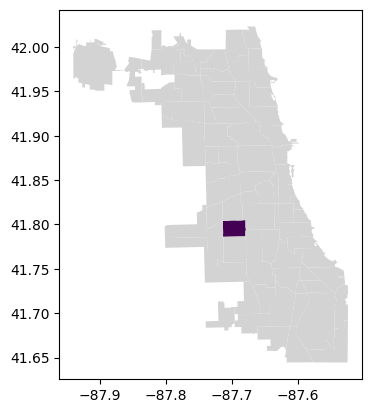

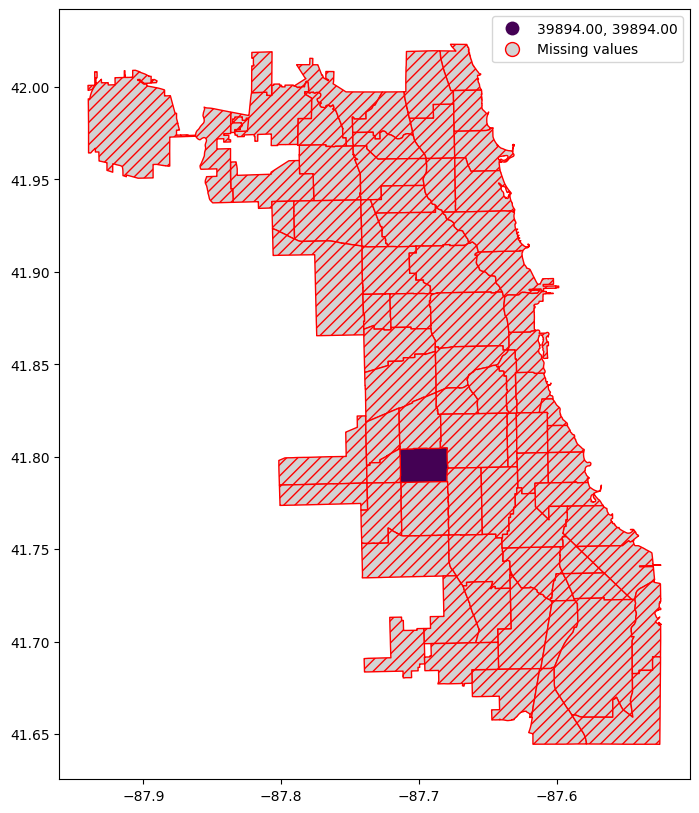

In [37]:
chicago.plot(column='POP2010', missing_kwds={'color': 'lightgrey'});

chicago.plot(
    column="POP2010",
    legend=True,
    scheme="quantiles",
    figsize=(15, 10),
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "red",
        "hatch": "///",
        "label": "Missing values",
    },
);

### Background tiles

## Maps with layers

There are two strategies for making a map with multiple layers - one more succint, and one that is a lttle more flexible. Before combining maps, however, remember to always ensure they share a common CRS (so they will align).

Method 1: Let GeoPandas create the matplotlib figure
    The simple way is to the let the first call to 'plot' define the 'Axes' which can be consumed by subsequent 'plot' calls via the 'ax' keyword.

Method 2: Create the matplotlib figure manually
    The other way is to define the 'Axes' object before and pass it to both.

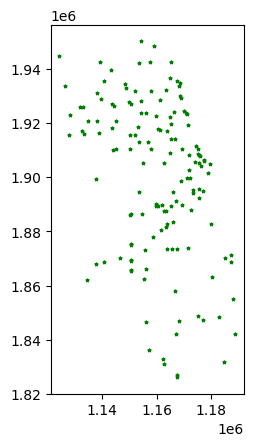

In [ ]:
## Note use of standard `pyplot` line style options
groceries.plot(marker='*', color='green', markersize=5);            # Look at groceries

groceries = groceries.to_crs(chicago.crs)                           # Check crs

### Method 1: Let GeoPandas create the matplotlib figure

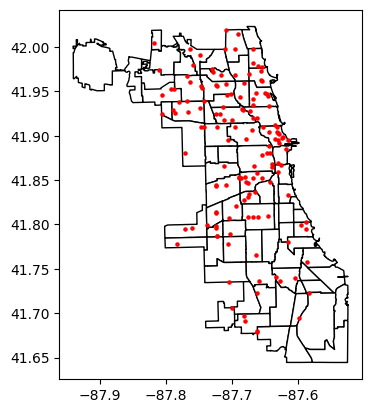

In [45]:
base = chicago.plot(color='white', edgecolor='black')

groceries.plot(ax=base, marker='o', color='red', markersize=5);

### Method 2: Create the matplotlib figure manually

<Axes: >

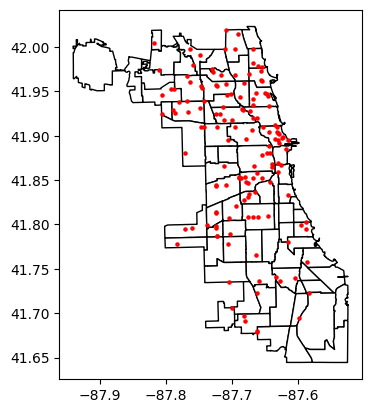

In [ ]:
fig, ax = plt.subplots()

chicago.plot(ax=ax, color='white', edgecolor='black')

groceries.plot(ax=ax, marker='o', color='red', markersize=5)